---
#Imports
---

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import kurtosis as scipy_kurtosis, entropy as scipy_entropy
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

cartella_grafici     = "/content/drive/MyDrive/Tesi/Grafici"
cartella_checkpoints = "/content/drive/MyDrive/Tesi/checkpoints_binario"
os.makedirs(cartella_checkpoints, exist_ok=True)

IMG_SIZE = (224, 224)

Mounted at /content/drive


---
#Normalizzazione (non runnare)
---

In [ ]:
#Runnare una volta sola
min_vel, max_vel   = np.inf, -np.inf
min_time, max_time = np.inf, -np.inf

for sim in sorted(os.listdir(cartella_grafici)):
    cartella_sim = os.path.join(cartella_grafici, sim)
    if not os.path.isdir(cartella_sim): continue
    if not sim.startswith("Simulazione"): continue

    for evento in sorted(os.listdir(cartella_sim)):
        cartella_ev = os.path.join(cartella_sim, evento)
        if not os.path.isdir(cartella_ev): continue

        path_vel  = os.path.join(cartella_ev, "slip_profile.png")
        path_time = os.path.join(cartella_ev, "slip_profile_time.png")

        if os.path.exists(path_vel):
            img = np.array(Image.open(path_vel).convert("L"), dtype=np.float32)
            min_vel = min(min_vel, img.min())
            max_vel = max(max_vel, img.max())

        if os.path.exists(path_time):
            img = np.array(Image.open(path_time).convert("L"), dtype=np.float32)
            min_time = min(min_time, img.min())
            max_time = max(max_time, img.max())

print(f"slip_profile      → min: {min_vel:.2f}, max: {max_vel:.2f}")
print(f"slip_profile_time → min: {min_time:.2f}, max: {max_time:.2f}")

np.save(os.path.join(cartella_grafici, "norm_vel.npy"),  np.array([min_vel, max_vel]))
np.save(os.path.join(cartella_grafici, "norm_time.npy"), np.array([min_time, max_time]))
print("Valori di normalizzazione salvati.")

---
#Dataset formazione (non runnare)
---

In [ ]:
def calcola_feature_texture(img_vel, img_time):
    """Le 8 feature più importanti emerse dal Random Forest per sigma_n."""
    gy_v, gx_v = np.gradient(img_vel)
    grad_v = np.sqrt(gx_v**2 + gy_v**2)
    gy_t, gx_t = np.gradient(img_time)
    grad_t = np.sqrt(gx_t**2 + gy_t**2)

    flat_v = img_vel.flatten()
    hist_v, _ = np.histogram(flat_v, bins=32, range=(flat_v.min(), flat_v.max() + 1e-9))
    hist_v_norm = hist_v / (hist_v.sum() + 1e-9)

    return np.array([
        grad_v.std(),                      # vel_grad_std
        grad_v.mean(),                     # vel_grad_media
        flat_v.std(),                      # vel_std
        grad_t.mean(),                     # time_grad_media
        img_time.flatten().std(),          # time_std
        grad_t.std(),                      # time_grad_std
        scipy_entropy(hist_v_norm + 1e-9), # vel_entropia
        scipy_kurtosis(flat_v),            # vel_kurtosis
    ], dtype=np.float32)

In [ ]:
norm_vel  = np.load(os.path.join(cartella_grafici, "norm_vel.npy"))
norm_time = np.load(os.path.join(cartella_grafici, "norm_time.npy"))

X_vel, X_time, X_fase, X_texture_raw, Y, Sim_ID = [], [], [], [], [], []
eventi_caricati, eventi_saltati = 0, 0

for sim in sorted(os.listdir(cartella_grafici)):
    cartella_sim = os.path.join(cartella_grafici, sim)
    if not os.path.isdir(cartella_sim): continue
    if not sim.startswith("Simulazione"): continue

    for evento in sorted(os.listdir(cartella_sim)):
        cartella_ev  = os.path.join(cartella_sim, evento)
        path_vel     = os.path.join(cartella_ev, "slip_profile.png")
        path_time    = os.path.join(cartella_ev, "slip_profile_time.png")
        path_meta    = os.path.join(cartella_ev, "dati.npz")

        if not all(os.path.exists(p) for p in [path_vel, path_time, path_meta]):
            eventi_saltati += 1
            continue

        img_vel  = np.array(Image.open(path_vel).convert("L").resize(IMG_SIZE), dtype=np.float32)
        img_vel  = (img_vel - norm_vel[0]) / (norm_vel[1] - norm_vel[0])

        img_time = np.array(Image.open(path_time).convert("L").resize(IMG_SIZE), dtype=np.float32)
        img_time = (img_time - norm_time[0]) / (norm_time[1] - norm_time[0])

        dati = np.load(path_meta, allow_pickle=True)
        meta = json.loads(str(dati['metadati']))

        fase = meta['tmin_s'] / meta['TMAX'] if meta['TMAX'] > 0 else 0.0
        texture = calcola_feature_texture(img_vel, img_time)

        X_vel.append(img_vel)
        X_time.append(img_time)
        X_fase.append(fase)
        X_texture_raw.append(texture)
        Y.append([meta['b'], meta['Dc_m'], meta['sigma_n_Pa']])
        Sim_ID.append(meta['simulazione_n'])
        eventi_caricati += 1

X_vel         = np.array(X_vel)[..., np.newaxis]
X_time        = np.array(X_time)[..., np.newaxis]
X_fase        = np.array(X_fase, dtype=np.float32).reshape(-1, 1)
X_texture_raw = np.array(X_texture_raw, dtype=np.float32)
Y             = np.array(Y, dtype=np.float32)
Sim_ID        = np.array(Sim_ID)

print(f"Eventi caricati: {eventi_caricati}")
print(f"Eventi saltati:  {eventi_saltati}")
print(f"X_vel shape:     {X_vel.shape}")
print(f"X_time shape:    {X_time.shape}")
print(f"X_fase shape:    {X_fase.shape}")
print(f"Range fase:      [{X_fase.min():.3f}, {X_fase.max():.3f}]")
print(f"X_texture_raw shape: {X_texture_raw.shape}")
print(f"Y shape:         {Y.shape}")

In [ ]:
#Salva il dataset dopo averlo caricato — eseguire una volta sola
np.savez_compressed(
    os.path.join(cartella_grafici, "dataset_completo.npz"),
    X_vel=X_vel,
    X_time=X_time,
    X_fase=X_fase,
    X_texture_raw=X_texture_raw,
    Y=Y,
    Sim_ID=Sim_ID)
print("Dataset salvato.")

---
#Caricamento del dataset
---

In [ ]:
#Carica il dataset salvato — stesso file usato dal notebook con sigma_n in regressione
dati = np.load(os.path.join(cartella_grafici, "dataset_completo.npz"))
X_vel         = dati["X_vel"]
X_time        = dati["X_time"]
X_fase        = dati["X_fase"]
X_texture_raw = dati["X_texture_raw"]
Y             = dati["Y"]
Sim_ID        = dati["Sim_ID"]
print(f"Dataset caricato: {len(Y)} eventi")

Dataset caricato: 4344 eventi


In [ ]:
#Normalizzazione: b e Dc restano regressione; sigma_n diventa un'etichetta binaria
Y_min = np.array([Y[:, 0].min(), Y[:, 1].min(), 0.0], dtype=np.float32)
Y_max = np.array([Y[:, 0].max(), Y[:, 1].max(), 1.0], dtype=np.float32)

Y_norm = np.stack([
    (Y[:, 0] - Y_min[0]) / (Y_max[0] - Y_min[0]),
    (Y[:, 1] - Y_min[1]) / (Y_max[1] - Y_min[1]),
    np.where(Y[:, 2] > 90e6, 1.0, 0.0)
], axis=1).astype(np.float32)

#Salvate nella cartella dei checkpoint binari
np.save(os.path.join(cartella_checkpoints, "norm_Y_min.npy"), Y_min)
np.save(os.path.join(cartella_checkpoints, "norm_Y_max.npy"), Y_max)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_vel, Y_norm, groups=Sim_ID))

X_vel_train,  X_vel_test  = X_vel[train_idx],  X_vel[test_idx]
X_time_train, X_time_test = X_time[train_idx], X_time[test_idx]
X_fase_train, X_fase_test = X_fase[train_idx], X_fase[test_idx]
Y_train,      Y_test      = Y_norm[train_idx], Y_norm[test_idx]

tex_mean = X_texture_raw[train_idx].mean(axis=0)
tex_std  = X_texture_raw[train_idx].std(axis=0) + 1e-9
np.save(os.path.join(cartella_checkpoints, "tex_mean.npy"), tex_mean)
np.save(os.path.join(cartella_checkpoints, "tex_std.npy"),  tex_std)

X_texture_train = (X_texture_raw[train_idx] - tex_mean) / tex_std
X_texture_test  = (X_texture_raw[test_idx]  - tex_mean) / tex_std

print(f"Training: {len(Y_train)} eventi ({len(np.unique(Sim_ID[train_idx]))} simulazioni)")
print(f"Test:     {len(Y_test)} eventi ({len(np.unique(Sim_ID[test_idx]))} simulazioni)")

#Bilanciamento di sigma_n
sigma_discreto = np.where(Y[train_idx, 2] > 90e6, "100", "80")
pesi_sigma_train = compute_sample_weight(class_weight='balanced', y=sigma_discreto)
pesi_sigma_train = np.clip(pesi_sigma_train, 0.2, 5.0)

Training: 3593 eventi (184 simulazioni)
Test:     751 eventi (47 simulazioni)


---
#Architettura CNN con due rami paralleli
---

In [ ]:
def build_model(input_shape=(224, 224, 1), n_texture=8):

    def cnn_branch(input_tensor, name):
        x = layers.Conv2D(32, (3,3), activation="relu", padding="same", name=f"{name}_conv1")(input_tensor)
        x = layers.BatchNormalization(name=f"{name}_bn1")(x)
        x = layers.MaxPooling2D(name=f"{name}_pool1")(x)

        x = layers.Conv2D(64, (3,3), activation="relu", padding="same", name=f"{name}_conv2")(x)
        x = layers.BatchNormalization(name=f"{name}_bn2")(x)
        x = layers.MaxPooling2D(name=f"{name}_pool2")(x)

        x = layers.Conv2D(128, (3,3), activation="relu", padding="same", name=f"{name}_conv3")(x)
        x = layers.BatchNormalization(name=f"{name}_bn3")(x)
        x = layers.MaxPooling2D(name=f"{name}_pool3")(x)

        x = layers.GlobalAveragePooling2D(name=f"{name}_gap")(x)
        return x

    input_vel     = keras.Input(shape=input_shape, name="slip_profile_vel")
    input_time    = keras.Input(shape=input_shape, name="slip_profile_time")
    input_fase    = keras.Input(shape=(1,), name="fase_ciclo")
    input_texture = keras.Input(shape=(n_texture,), name="texture_features")

    branch_vel     = cnn_branch(input_vel,  "vel")
    branch_time    = cnn_branch(input_time, "time")
    branch_fase    = layers.Dense(8, activation="relu", name="fase_dense")(input_fase)
    branch_texture = layers.Dense(16, activation="relu", name="texture_dense1")(input_texture)
    branch_texture = layers.Dense(16, activation="relu", name="texture_dense2")(branch_texture)

    fusion = layers.Concatenate(name="fusion")([branch_vel, branch_time, branch_fase, branch_texture])
    fusion = layers.Dense(256, activation="relu", name="dense1")(fusion)
    fusion = layers.Dropout(0.2, name="dropout1")(fusion)
    fusion = layers.Dense(64, activation="relu", name="dense2")(fusion)
    fusion = layers.Dropout(0.1, name="dropout2")(fusion)

    ramo_b = layers.Dense(64, activation="relu", name="b_dense1")(fusion)
    ramo_b = layers.Dropout(0.05, name="b_dropout")(ramo_b)
    ramo_b = layers.Dense(32, activation="relu", name="b_dense2")(ramo_b)
    out_b  = layers.Dense(1, activation="sigmoid", name="output_b")(ramo_b)

    out_Dc    = layers.Dense(1, activation="sigmoid", name="output_Dc")(fusion)

    out_sigma = layers.Dense(1, activation="sigmoid", name="output_sigma")(fusion)

    model = keras.Model(
        inputs=[input_vel, input_time, input_fase, input_texture],
        outputs=[out_b, out_Dc, out_sigma])
    return model

model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ slip_profile_vel    │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slip_profile_time   │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vel_conv1 (Conv2D)  │ (None, 224, 224,  │        320 │ slip_profile_vel… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_conv1 (Conv2D) │ (None, 224, 224,  │        320 │ slip_profile_tim… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vel_bn1             │ (None, 224, 224,  │        128 │ vel_conv1[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_bn1            │ (None, 224, 224,  │        128 │ time_conv1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vel_pool1           │ (None, 112, 112,  │          0 │ vel_bn1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_pool1          │ (None, 112, 112,  │          0 │ time_bn1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vel_conv2 (Conv2D)  │ (None, 112, 112,  │     18,496 │ vel_pool1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_conv2 (Conv2D) │ (None, 112, 112,  │     18,496 │ time_pool1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vel_bn2             │ (None, 112, 112,  │        256 │ vel_conv2[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_bn2            │ (None, 112, 112,  │        256 │ time_conv2[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vel_pool2           │ (None, 56, 56,    │          0 │ vel_bn2[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_pool2          │ (None, 56, 56,    │          0 │ time_bn2[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vel_conv3 (Conv2D)  │ (None, 56, 56,    │     73,856 │ vel_pool2[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_conv3 (Conv2D) │ (None, 56, 56,    │     73,856 │ time_pool2[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vel_bn3             │ (None, 56, 56,    │        512 │ vel_conv3[0][0] 

 Total params: 282,355 (1.08 MB)

 Trainable params: 281,459 (1.07 MB)

 Non-trainable params: 896 (3.50 KB)

---
#Training con checkpoint
---

In [ ]:
#Percorso checkpoint — cartella dedicata al modello binario
ckpt_best      = os.path.join(cartella_checkpoints, "model_best.keras")
ckpt_periodico = os.path.join(cartella_checkpoints, "model_epoch_{epoch:03d}.keras")

#Carica checkpoint se esiste
resume = True
if resume and os.path.exists(ckpt_best):
    model = keras.models.load_model(ckpt_best)
    print(f"Checkpoint caricato: {ckpt_best}")
else:
    model = build_model()
    print("Nessun checkpoint trovato, si parte da zero.")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=["huber", "mse", "binary_crossentropy"],   #Huber per b, invariato Dc, binaria per sigma_n
    loss_weights=[1.0, 1.0, 1.0],
    metrics=[["mae"], ["mae"], ["accuracy"]]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath=ckpt_best, monitor="val_loss", save_best_only=True, verbose=1),
    keras.callbacks.ModelCheckpoint(filepath=ckpt_periodico, save_freq=10, verbose=0),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1)
]

history = model.fit(
    x={
        "slip_profile_vel":  X_vel_train,
        "slip_profile_time": X_time_train,
        "fase_ciclo":        X_fase_train,
        "texture_features":  X_texture_train,
    },
    y=[Y_train[:, 0], Y_train[:, 1], Y_train[:, 2]],
    sample_weight=[
        np.ones(len(Y_train)),
        np.ones(len(Y_train)),
        pesi_sigma_train,
    ],
    validation_data=(
        {
            "slip_profile_vel":  X_vel_test,
            "slip_profile_time": X_time_test,
            "fase_ciclo":        X_fase_test,
            "texture_features":  X_texture_test,
        },
        [Y_test[:, 0], Y_test[:, 1], Y_test[:, 2]]
    ),
    epochs=500,
    batch_size=32,
    callbacks=callbacks
)

In [ ]:
print(f"Epoche completate: {len(history.history['loss'])}")
print(f"Loss totale finale training:   {history.history['loss'][-1]:.6f}")
print(f"Loss totale finale validation: {history.history['val_loss'][-1]:.6f}")
print()

for chiave_metrica, nome_display in [("output_b_mae", "b (MAE)"), ("output_Dc_mae", "Dc (MAE)")]:
    val_train = history.history[chiave_metrica][-1]
    val_val   = history.history[f"val_{chiave_metrica}"][-1]
    print(f"{nome_display:<12} — training: {val_train:.6f}  |  validation: {val_val:.6f}")

acc_train = history.history["output_sigma_accuracy"][-1]
acc_val   = history.history["val_output_sigma_accuracy"][-1]
print(f"{'sigma_n (acc.)':<12} — training: {acc_train:.6f}  |  validation: {acc_val:.6f}")

print(f"\nMiglior val_loss: {min(history.history['val_loss']):.6f}")
print(f"Raggiunta all'epoca: {history.history['val_loss'].index(min(history.history['val_loss'])) + 1}")

---
#Grafici training
---

In [ ]:
model = keras.models.load_model(os.path.join(cartella_checkpoints, "model_best.keras"))

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(history.history["loss"],     label="Training")
axes[0,0].plot(history.history["val_loss"], label="Validation")
axes[0,0].set_title("Loss totale (somma pesata)")
axes[0,0].set_xlabel("Epoca"); axes[0,0].set_ylabel("Loss")
axes[0,0].legend(); axes[0,0].grid(True, linestyle=":", alpha=0.6)

parametri_loss = [("output_b_loss", "b (Huber)"), ("output_Dc_loss", "Dc (MSE)"), ("output_sigma_loss", "sigma_n (BCE)")]
posizioni = [(0,1), (1,0), (1,1)]

for (chiave, nome), (r, c) in zip(parametri_loss, posizioni):
    axes[r,c].plot(history.history[chiave],          label="Training")
    axes[r,c].plot(history.history[f"val_{chiave}"], label="Validation")
    axes[r,c].set_title(f"Loss — {nome}")
    axes[r,c].set_xlabel("Epoca"); axes[r,c].set_ylabel("Loss")
    axes[r,c].legend(); axes[r,c].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

#MAE per b e Dc, accuracy per sigma_n
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (chiave, nome) in enumerate([("output_b_mae", "b (MAE)"), ("output_Dc_mae", "Dc (MAE)")]):
    axes[i].plot(history.history[chiave],          label="Training")
    axes[i].plot(history.history[f"val_{chiave}"], label="Validation")
    axes[i].set_title(nome)
    axes[i].set_xlabel("Epoca")
    axes[i].legend(); axes[i].grid(True, linestyle=":", alpha=0.6)

axes[2].plot(history.history["output_sigma_accuracy"],     label="Training")
axes[2].plot(history.history["val_output_sigma_accuracy"], label="Validation")
axes[2].set_title("sigma_n (Accuracy)")
axes[2].set_xlabel("Epoca")
axes[2].legend(); axes[2].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

---
#Validation
---

24/24 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step
Parametro                MAE         RMSE
------------------------------------------
b                 6.1735e-04   7.5262e-04
Dc [m]            3.6152e-07   4.7504e-07
sigma_n (acc.)         0.752


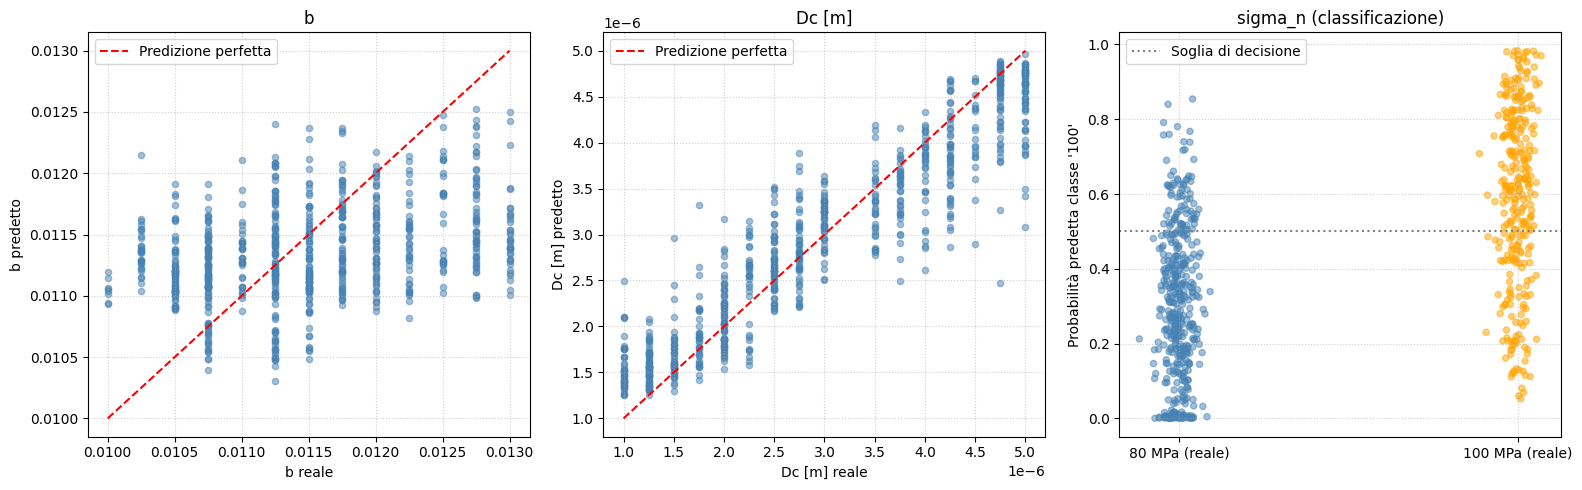

In [ ]:
Y_min = np.load(os.path.join(cartella_checkpoints, "norm_Y_min.npy"))
Y_max = np.load(os.path.join(cartella_checkpoints, "norm_Y_max.npy"))

pred_list = model.predict(
    {
        "slip_profile_vel":  X_vel_test,
        "slip_profile_time": X_time_test,
        "fase_ciclo":        X_fase_test,
        "texture_features":  X_texture_test,
    }
)
Y_pred_norm = np.concatenate(pred_list, axis=1)

Y_pred = Y_pred_norm * (Y_max - Y_min) + Y_min
Y_real = Y_test      * (Y_max - Y_min) + Y_min

print(f"{'Parametro':<15} {'MAE':>12} {'RMSE':>12}")
print("-" * 42)
for i, nome in enumerate(["b", "Dc [m]"]):
    mae  = np.mean(np.abs(Y_pred[:, i] - Y_real[:, i]))
    rmse = np.sqrt(np.mean((Y_pred[:, i] - Y_real[:, i])**2))
    print(f"{nome:<15} {mae:>12.4e} {rmse:>12.4e}")

accuracy_sigma = ((Y_pred[:, 2] > 0.5).astype(int) == Y_real[:, 2].astype(int)).mean()
print(f"{'sigma_n (acc.)':<15} {accuracy_sigma:>12.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, nome in enumerate(["b", "Dc [m]"]):
    axes[i].scatter(Y_real[:, i], Y_pred[:, i], alpha=0.5, s=20, color="steelblue")
    lim = [min(Y_real[:, i].min(), Y_pred[:, i].min()),
           max(Y_real[:, i].max(), Y_pred[:, i].max())]
    axes[i].plot(lim, lim, "r--", lw=1.5, label="Predizione perfetta")
    axes[i].set_xlabel(f"{nome} reale"); axes[i].set_ylabel(f"{nome} predetto")
    axes[i].set_title(nome); axes[i].legend()
    axes[i].grid(True, linestyle=":", alpha=0.6)

jitter = np.random.default_rng(0).normal(0, 0.03, size=len(Y_real))
colori = np.where(Y_real[:, 2] == 1, "orange", "steelblue")
axes[2].scatter(Y_real[:, 2] + jitter, Y_pred[:, 2], alpha=0.5, s=20, c=colori)
axes[2].axhline(0.5, color="gray", linestyle=":", label="Soglia di decisione")
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["80 MPa (reale)", "100 MPa (reale)"])
axes[2].set_ylabel("Probabilità predetta classe '100'")
axes[2].set_title("sigma_n (classificazione)")
axes[2].legend(); axes[2].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

---
#Predici evento
---

In [ ]:
def predici_evento(path_vel, path_time):
    norm_vel  = np.load(os.path.join(cartella_grafici, "norm_vel.npy"))
    norm_time = np.load(os.path.join(cartella_grafici, "norm_time.npy"))
    Y_min     = np.load(os.path.join(cartella_checkpoints, "norm_Y_min.npy"))
    Y_max     = np.load(os.path.join(cartella_checkpoints, "norm_Y_max.npy"))
    tex_mean  = np.load(os.path.join(cartella_checkpoints, "tex_mean.npy"))
    tex_std   = np.load(os.path.join(cartella_checkpoints, "tex_std.npy"))

    cartella_ev = os.path.dirname(path_vel)
    path_meta   = os.path.join(cartella_ev, "dati.npz")

    dati = np.load(path_meta, allow_pickle=True)
    meta = json.loads(str(dati['metadati']))
    tmin_s = meta['tmin_s']
    TMAX   = meta['TMAX']

    img_vel_raw  = np.array(Image.open(path_vel).convert("L").resize(IMG_SIZE), dtype=np.float32)
    img_vel  = (img_vel_raw - norm_vel[0]) / (norm_vel[1] - norm_vel[0])

    img_time_raw = np.array(Image.open(path_time).convert("L").resize(IMG_SIZE), dtype=np.float32)
    img_time = (img_time_raw - norm_time[0]) / (norm_time[1] - norm_time[0])

    fase = tmin_s / TMAX if TMAX > 0 else 0.0
    texture = calcola_feature_texture(img_vel, img_time)
    texture_norm = (texture - tex_mean) / tex_std

    pred_list = model.predict(
        {
            "slip_profile_vel":  img_vel[np.newaxis, ..., np.newaxis],
            "slip_profile_time": img_time[np.newaxis, ..., np.newaxis],
            "fase_ciclo":        np.array([[fase]], dtype=np.float32),
            "texture_features":  texture_norm[np.newaxis, :],
        },
        verbose=0
    )
    pred_norm = np.array([p[0, 0] for p in pred_list])
    pred_b_Dc = pred_norm[:2] * (Y_max[:2] - Y_min[:2]) + Y_min[:2]
    prob_sigma_100 = pred_norm[2]
    classe_sigma = "100 MPa" if prob_sigma_100 > 0.5 else "80 MPa"

    print("─" * 45)
    print(f"{'Parametro':<20} {'Predetto':>20}")
    print("─" * 45)
    print(f"{'b':<20} {pred_b_Dc[0]:>20.4e}")
    print(f"{'Dc [m]':<20} {pred_b_Dc[1]:>20.4e}")
    print(f"{'sigma_n (classe)':<20} {classe_sigma:>20}")
    print(f"{'P(sigma_n=100 MPa)':<20} {prob_sigma_100:>20.3f}")
    print("─" * 45)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(Image.open(path_vel))
    axes[0].set_title("Slip profile (velocita')")
    axes[0].axis("off")
    axes[1].imshow(Image.open(path_time))
    axes[1].set_title("Slip profile (tempo)")
    axes[1].axis("off")
    plt.suptitle(
        f"b = {pred_b_Dc[0]:.4e}   |   Dc = {pred_b_Dc[1]:.4e} m   |   σn predetto = {classe_sigma} (P={prob_sigma_100:.2f})",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

    return pred_b_Dc, classe_sigma, prob_sigma_100

---
#Utilizzo
---

In [ ]:
pred = predici_evento(
    path_vel  = "/content/drive/MyDrive/Tesi/Grafici/Simulazione_46_20260706/Evento_005/slip_profile.png",
    path_time = "/content/drive/MyDrive/Tesi/Grafici/Simulazione_46_20260706/Evento_005/slip_profile_time.png")

In [ ]:
path_meta_check = "/content/drive/MyDrive/Tesi/Grafici/Simulazione_46_20260706/Evento_005/dati.npz"
dati_check = np.load(path_meta_check, allow_pickle=True)
meta_check = json.loads(str(dati_check['metadati']))

print(f"b:            {meta_check['b']}")
print(f"Dc [m]:       {meta_check['Dc_m']}")
print(f"sigma_n [Pa]: {meta_check['sigma_n_Pa']}")
print(f"simulazione_n: {meta_check['simulazione_n']}")